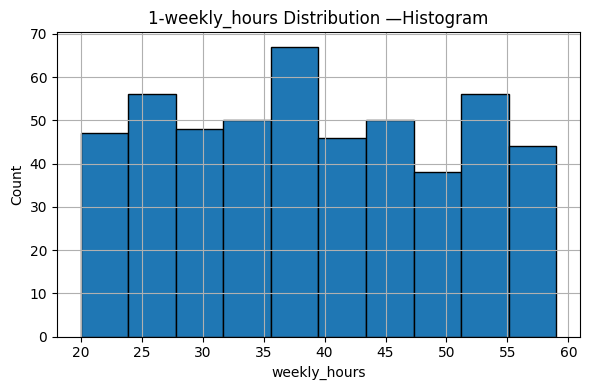

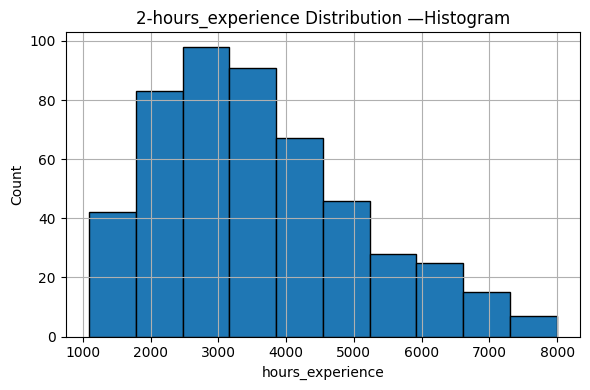

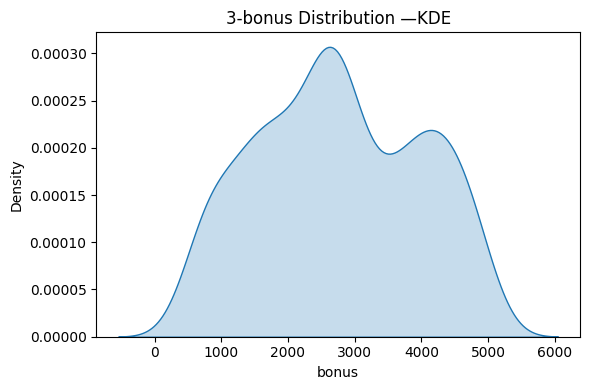

{'1- weekly_hours Distribution —Histogram': 'it is uniform(symmetric)', '2-hours_experience ': 'it is skewed', '3-bonus Distribution —KDE': 'it is bimodal'}


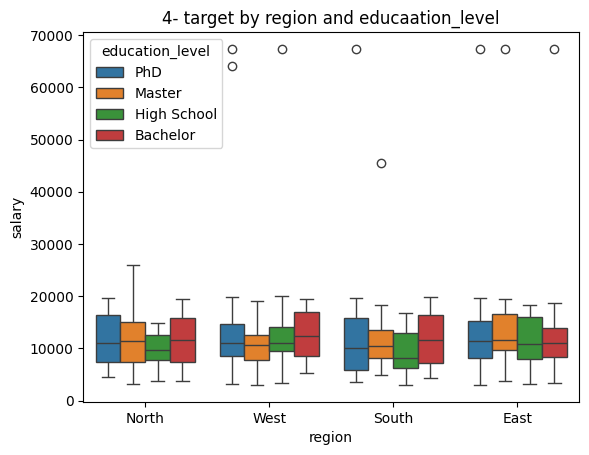

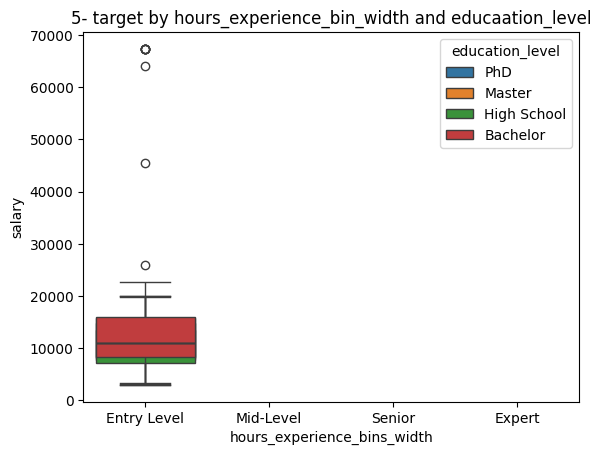

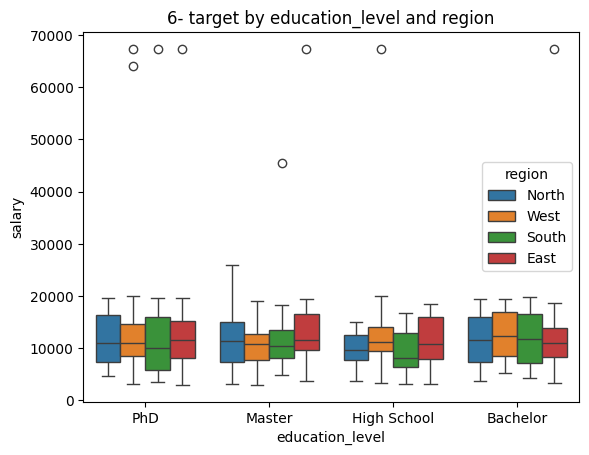

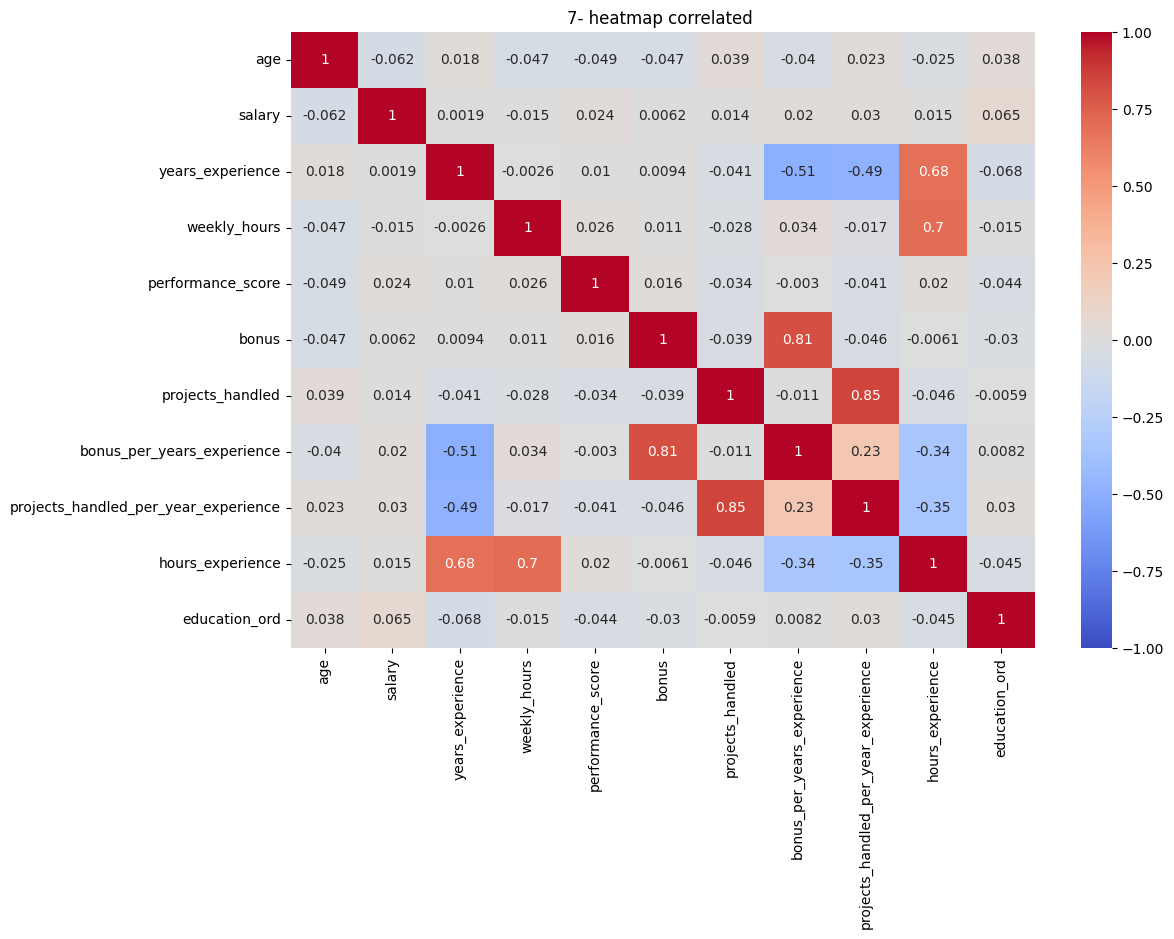

the top 10 features most correlated with the target : 
1-bonus_per_years_experience 
2-projects_handled_per_year_experience 
3-education_ord 
4-age_log1p 
5-performance_score 
6-hours_experience 
7-weekly_hours 
8-projects_handled 
9-bonus 
10-years_experience


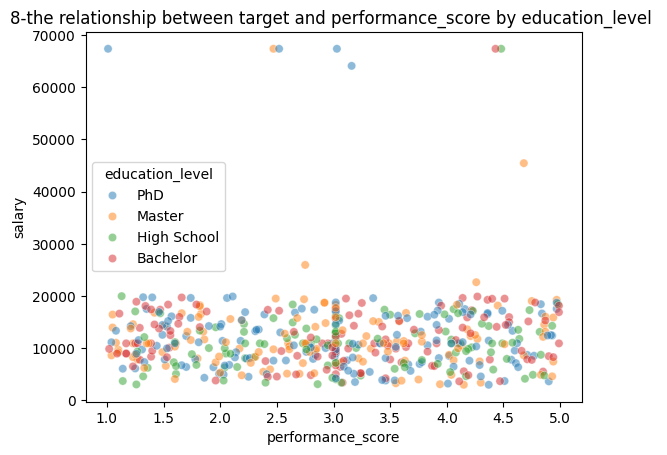

the highest groub is : (phD : 12735.319281) , the lowest groub is:(High school :11084.047596 )
insights:
1- weekly_hours Distribution : it is uniform(symmetric);It is perfect and doesn't need any modification. It won't negatively affect the model's prediction.
2-hours_experience Distribution : it is right skewed;  consider log transform before modeling. 
3-bonus Distribution —KDE : it is bimodal; it is ok but you might find two predictions when Prediction 
4-target by region and educaation_level: the values are close but there is some outliers; remove outliers 
5- target by hours_experience_bin_width and educaation_level:the values are close but there is some outliers; remove outliers  
6- target by education_level and region: the values are close but there is some outliers; remove outliers7- heatmap correlated: two columns are strongly correlated ; one may be redundant. 
8-the relationship between target and performance_score by education_level: there are some outliers, may affect the

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import cleaning_01 as r
import features_02 as f

df6 = f.df6.copy()





count= 1

numeric_col1 = ['weekly_hours', 'hours_experience']
for col in numeric_col1:
  plt.figure(figsize=(6, 4))
  df6[col].hist(bins=10, edgecolor="black")# plot distributions of two numeric columns by using histplot
  plt.title(f"{count}-{col} Distribution —Histogram")
  plt.xlabel(col); plt.ylabel("Count")
  plt.tight_layout(); plt.show()
  count+=1 # counter
plt.figure(figsize=(6, 4))
sns.kdeplot(df6["bonus"], fill=True)## plot distributions of a numeric columns by using histplot
plt.title("3-bonus Distribution —KDE")
plt.xlabel("bonus"); plt.ylabel("Density")
plt.tight_layout(); plt.show()

discribe = {'1- weekly_hours Distribution —Histogram':'it is uniform(symmetric)',
            '2-hours_experience ' : 'it is skewed',
            '3-bonus Distribution —KDE': 'it is bimodal'
}
print(discribe)
target = 'salary'

# boxplot for comparing
sns.boxplot(data=df6, x="region", y=target, hue="education_level")
plt.title('4- target by region and educaation_level');plt.show()#
sns.boxplot(data=df6, x="hours_experience_bins_width", y=target, hue="education_level")
plt.title('5- target by hours_experience_bin_width and educaation_level');plt.show()
sns.boxplot(data=df6, x="education_level", y=target, hue="region")
plt.title('6- target by education_level and region');plt.show()

numeric =  ['age' ,  'salary' , 'years_experience' , 'weekly_hours' , 'performance_score' , 'bonus' , 'projects_handled',
'bonus_per_years_experience','projects_handled_per_year_experience',
'hours_experience','education_ord']
corr_matrix = df6[numeric].corr()# see correlated
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)# seeing the correlated in heattmap plot
plt.title('7- heatmap correlated ');plt.show()

print('the top 10 features most correlated with the target :','\n1-bonus_per_years_experience','\n2-projects_handled_per_year_experience',
  '\n3-education_ord','\n4-age_log1p','\n5-performance_score','\n6-hours_experience',
 '\n7-weekly_hours','\n8-projects_handled','\n9-bonus','\n10-years_experience')
# using scatter plot to see relationship
sns.scatterplot(data=df6, x="performance_score", y="salary", alpha=0.5, hue= 'education_level')
plt.title('8-the relationship between target and performance_score by education_level ');plt.show()


education_level_summary = df6.groupby("education_level")[["salary"]].agg(
["mean"]
)
max1 = education_level_summary.max()
min1 =education_level_summary.min()
print(f'the highest groub is : (phD : 12735.319281) , the lowest groub is:(High school :11084.047596 )')


insights = ["insights:",
            "1- weekly_hours Distribution : it is uniform(symmetric);It is perfect and doesn't need any modification. It won't negatively affect the model's prediction.",
           "2-hours_experience Distribution : it is right skewed;  consider log transform before modeling. ",
           "3-bonus Distribution —KDE : it is bimodal; it is ok but you might find two predictions when Prediction ",
           "4-target by region and educaation_level: the values are close but there is some outliers; remove outliers ",
           "5- target by hours_experience_bin_width and educaation_level:the values are close but there is some outliers; remove outliers  ",
           "6- target by education_level and region: the values are close but there is some outliers; remove outliers"
           "7- heatmap correlated: two columns are strongly correlated ; one may be redundant. ",
           "8-the relationship between target and performance_score by education_level: there are some outliers, may affect the relationship ; remove outliers "
           ]


for i in insights:
  print(i)





#MATH_BASICS

print()
print()
# the mean of the target manually
sum_target = df6[target].sum()
mean_target = sum_target / len(df6[target])
print( 'the mean of the target is :',mean_target)

# the standard deviation of the target manually
std_step1=  df6[target] - mean_target
std_step2 = std_step1 ** 2
std_step3 = std_step2.sum()
std_step4 = std_step3 / 501

std_step5 =np.sqrt(std_step4)
print('the  standard deviation (std) of the target manually :',std_step5)
print('std=',df6[target].std())
print('they are the same')

# Standardise one column by hand using broadcasting
y= []

for i in df6['weekly_hours']:
  y.append(i)

X = np.array(y)
means = X.mean(axis=0, keepdims=True)
stds = X.std(axis=0, keepdims=True)
X_std = (X -means) / stds


#Compute cosine similarity
def cosine_similarity(a, b):
  return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))#  the formula
v = np.array( [ 21.0 ,  3009.0 , 20.34413  , 51.0   ,   4.15   ,  2690.0  , 4.0 , 2  , -0.011398  ,
                 1.049394  ,  147.905075  ,   0.196617  ,  1037.550607  ,  3.091042  ,  1.048349])
u = np.array([24.0 , 67356.95 ,16.0 ,31.0 , 2.47  , 3947.0  , 9.0 , 2 , -0.40067 ,
              -0.728872 , 4209.809375 ,  0.5625  ,496.0 , 3.218876 , -0.728145])
print("cos(u, v):", cosine_similarity(u, v))

# Estimate a probability

count = 0
high_quality_space = []
# determine high quality items
for i in df6['performance_score'] :
  data = count,i
  count+=1
  if data[1] >= 3:
    lf =df6.iloc[data[0]]
    if lf['salary'] > 15000:
      high_quality_space.append(lf['salary'])

#Finding the percentage of those who pass to reduce from high quality items
event_high = [x for x in high_quality_space if x >= 50000]
print("P(high) =", len(event_high)/len(high_quality_space))










